# Covasim Graph Generation & Distance Comparison

Questo notebook:
1. Genera **3 tipologie × 3 grafi = 9 grafi** da simulazioni covasim con modelli di generazione diversi:
   - **A — Random**: layer unico, mixing omogeneo (`pop_type='random'`)
   - **B — Hybrid standard**: 4 layer (household/school/work/community), struttura per età (`pop_type='hybrid'`, default)
   - **C — Hybrid household-heavy**: stessa struttura di B ma contatti household dominanti (`pop_type='hybrid'`, `contacts={h:8, s:5, w:5, c:5}`)
2. Calcola embedding EDRep per ogni grafo
3. Misura tutte le distanze a coppie con 3 metriche:
   - **EmbDistance** (distanza spettrale unmatched)
   - **w2_distance** (Wasserstein sulla matrice di Gram completa)
   - **w2_distance_classes** (Wasserstein per partizione sesso: femmina / maschio)
4. Visualizza le 3 matrici di distanza 9×9 come heatmap
5. Valuta quale metrica separa meglio le tipologie tramite **Silhouette Score** e **Between/Within ratio**

## 1. Setup

In [1]:
# Uncomment to install covasim if not already available
# !pip install covasim

In [2]:
import sys
import os

# Add project root to path so we can import functions.py and EDRep_main
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import networkx as nx
import ot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import covasim as cv

from sklearn.metrics import silhouette_score
from EDRep_main.EDRep import NodeEmbedding
from functions import w2_distance_classes

Covasim 3.1.7 (2026-02-18) — © 2020-2026 by IDM


## 2. Graph Generation

In [3]:
def covasim_graph(pop_size=200, seed=0, pop_type='random', contacts=None):
    """Run a covasim simulation and return the contact network as a NetworkX graph.
    
    pop_type: 'random' (single layer, homogeneous) or 'hybrid' (4 layers, age-structured)
    contacts: dict of contacts per layer, or None for covasim defaults
    """
    kwargs = dict(pop_size=pop_size, rand_seed=seed, pop_type=pop_type, verbose=0)
    if contacts is not None:
        kwargs['contacts'] = contacts
    sim = cv.Sim(**kwargs)
    sim.run()

    n = len(sim.people)  # covasim 3.x: use len() instead of .n
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Add edges from all available contact layers
    for layer in sim.people.contacts.values():
        edges = zip(layer['p1'].tolist(), layer['p2'].tolist())
        G.add_edges_from(edges)

    # Attach node attributes
    for i in range(n):
        G.nodes[i]['sex'] = int(sim.people.sex[i])   # 0 = female, 1 = male
        G.nodes[i]['age'] = float(sim.people.age[i])

    return G

In [4]:
POP_SIZE = 200
SEEDS    = [0, 1, 2]

# 3 graph types with structurally different generation models
GRAPH_TYPES = [
    {
        'label':    'A-Random',
        'pop_type': 'random',
        'contacts': {'a': 20},          # single homogeneous layer
        'desc':     'Homogeneous random mixing, single contact layer',
    },
    {
        'label':    'B-Hybrid-std',
        'pop_type': 'hybrid',
        'contacts': None,               # covasim defaults: {h:2, s:20, w:16, c:20}
        'desc':     'Realistic 4-layer network (household/school/work/community)',
    },
    {
        'label':    'C-Hybrid-hh',
        'pop_type': 'hybrid',
        'contacts': {'h': 8, 's': 5, 'w': 5, 'c': 5},  # household-dominated
        'desc':     'Household-heavy: dense local clusters, sparse other layers',
    },
]

graphs      = []   # 9 graphs in type order: A0,A1,A2, B0,B1,B2, C0,C1,C2
graph_labels = []  # short label per graph
type_labels  = []  # integer type id (0,1,2) per graph

for t_idx, gtype in enumerate(GRAPH_TYPES):
    print(f"\n--- Type {gtype['label']}: {gtype['desc']} ---")
    for seed in SEEDS:
        G = covasim_graph(pop_size=POP_SIZE, seed=seed,
                          pop_type=gtype['pop_type'], contacts=gtype['contacts'])
        n_female = sum(1 for _, d in G.nodes(data=True) if d['sex'] == 0)
        n_male   = sum(1 for _, d in G.nodes(data=True) if d['sex'] == 1)
        print(f"  seed={seed}: {G.number_of_nodes()} nodes, "
              f"{G.number_of_edges()} edges | female={n_female}, male={n_male}")
        graphs.append(G)
        graph_labels.append(f"{gtype['label'][:1]}-{seed}")
        type_labels.append(t_idx)

N = len(graphs)  # = 9
print(f"\nTotal: {N} graphs, labels: {graph_labels}")


--- Type A-Random: Homogeneous random mixing, single contact layer ---
  seed=0: 200 nodes, 1941 edges | female=94, male=106
  seed=1: 200 nodes, 1893 edges | female=97, male=103
  seed=2: 200 nodes, 1833 edges | female=108, male=92

--- Type B-Hybrid-std: Realistic 4-layer network (household/school/work/community) ---
  seed=0: 200 nodes, 3154 edges | female=94, male=106
  seed=1: 200 nodes, 3138 edges | female=97, male=103
  seed=2: 200 nodes, 3192 edges | female=108, male=92

--- Type C-Hybrid-hh: Household-heavy: dense local clusters, sparse other layers ---
  seed=0: 200 nodes, 1622 edges | female=94, male=106
  seed=1: 200 nodes, 1562 edges | female=97, male=103
  seed=2: 200 nodes, 1598 edges | female=108, male=92

Total: 9 graphs, labels: ['A-0', 'A-1', 'A-2', 'B-0', 'B-1', 'B-2', 'C-0', 'C-1', 'C-2']


## 3. Node Embeddings (EDRep)

In [5]:
def get_embedding(G, dim=16, seed=42):
    """Compute EDRep node embedding for graph G."""
    A = nx.to_scipy_sparse_array(G, format='csr')
    np.random.seed(seed)
    emb = NodeEmbedding(A, dim=dim, k=1, verbose=False)
    return emb.X

In [6]:
DIM = 16

embeddings = []
for i, G in enumerate(graphs):
    X = get_embedding(G, dim=DIM)
    embeddings.append(X)
    print(f"{graph_labels[i]}: embedding shape {X.shape}")

A-0: embedding shape (200, 16)
A-1: embedding shape (200, 16)
A-2: embedding shape (200, 16)
B-0: embedding shape (200, 16)
B-1: embedding shape (200, 16)
B-2: embedding shape (200, 16)
C-0: embedding shape (200, 16)
C-1: embedding shape (200, 16)
C-2: embedding shape (200, 16)


## 4. Distance Functions

In [7]:
def EmbDistance(X, Y, distance_type='unmatched'):
    """Embedding-based graph distance (spectral / unmatched or matched Frobenius)."""
    n1, d1 = X.shape
    n2, d2 = Y.shape

    if d1 != d2:
        raise ValueError('The embedding matrices have different dimensions')
    if distance_type not in ['unmatched', 'matched']:
        raise ValueError('distance_type must be unmatched or matched')
    if distance_type == 'matched' and n1 != n2:
        raise ValueError('Matched distance requires same number of nodes')

    if distance_type == 'matched':
        Mxx = X.T @ X
        Mxy = X.T @ Y
        Myy = Y.T @ Y
        return np.sqrt(np.abs(
            np.linalg.norm(Mxx)**2 + np.linalg.norm(Myy)**2 - 2*np.linalg.norm(Mxy)**2
        ))
    else:
        lam1 = np.linalg.eigvalsh(X.T @ X) / n1
        lam2 = np.linalg.eigvalsh(Y.T @ Y) / n2
        return np.linalg.norm(lam1 - lam2)


def w2_distance(emb_1, emb_2):
    """Wasserstein-2 distance between two embeddings via flattened Gram matrices."""
    vals_1 = (emb_1 @ emb_1.T).flatten()
    vals_2 = (emb_2 @ emb_2.T).flatten()
    return ot.wasserstein_1d(vals_1, vals_2, p=2)**(1/2)


def sex_partition(G, X):
    """Split embedding rows by sex attribute (0=female, 1=male)."""
    sexes = np.array([G.nodes[i]['sex'] for i in range(G.number_of_nodes())])
    return [X[sexes == 0], X[sexes == 1]]

## 5. Pairwise Distance Matrices

In [8]:
D_emb = np.zeros((N, N))
D_w2  = np.zeros((N, N))
D_cls = np.zeros((N, N))

for i in range(N):
    for j in range(i + 1, N):
        D_emb[i, j] = EmbDistance(embeddings[i], embeddings[j])
        D_w2 [i, j] = w2_distance(embeddings[i], embeddings[j])
        D_cls[i, j] = w2_distance_classes(
            sex_partition(graphs[i], embeddings[i]),
            sex_partition(graphs[j], embeddings[j])
        )[0]

        # Symmetrise
        D_emb[j, i] = D_emb[i, j]
        D_w2 [j, i] = D_w2 [i, j]
        D_cls[j, i] = D_cls[i, j]

print("EmbDistance matrix:\n", np.round(D_emb, 5))
print("\nw2_distance matrix:\n", np.round(D_w2, 5))
print("\nw2_distance_classes matrix:\n", np.round(D_cls, 5))

EmbDistance matrix:
 [[0.      0.0132  0.01039 0.05556 0.0354  0.05824 0.09383 0.09118 0.08276]
 [0.0132  0.      0.00872 0.05979 0.03991 0.06212 0.08735 0.08716 0.07711]
 [0.01039 0.00872 0.      0.05708 0.03717 0.05946 0.09027 0.08883 0.07887]
 [0.05556 0.05979 0.05708 0.      0.02216 0.00989 0.09804 0.08023 0.08679]
 [0.0354  0.03991 0.03717 0.02216 0.      0.02353 0.09288 0.08067 0.08071]
 [0.05824 0.06212 0.05946 0.00989 0.02353 0.      0.09795 0.08014 0.08598]
 [0.09383 0.08735 0.09027 0.09804 0.09288 0.09795 0.      0.03093 0.01951]
 [0.09118 0.08716 0.08883 0.08023 0.08067 0.08014 0.03093 0.      0.03055]
 [0.08276 0.07711 0.07887 0.08679 0.08071 0.08598 0.01951 0.03055 0.     ]]

w2_distance matrix:
 [[0.      0.00281 0.00291 0.01009 0.01122 0.01122 0.07855 0.06844 0.07595]
 [0.00281 0.      0.00242 0.00862 0.01108 0.00962 0.07794 0.06786 0.07552]
 [0.00291 0.00242 0.      0.00944 0.01094 0.01023 0.07786 0.06779 0.07537]
 [0.01009 0.00862 0.00944 0.      0.01065 0.00376 0.0739

## 6. Visualization

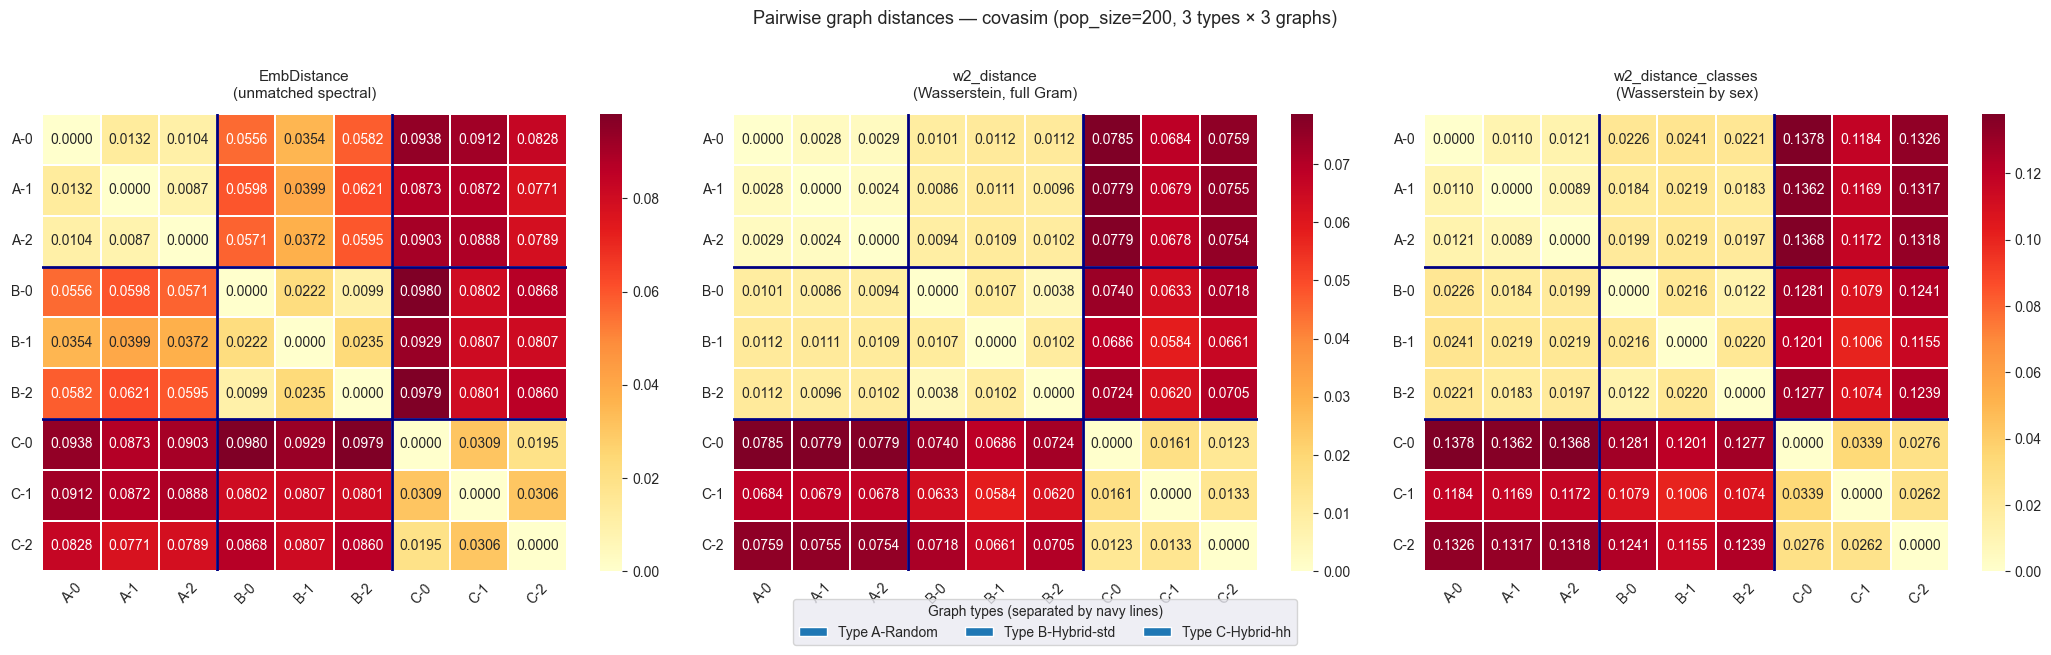

In [9]:
GROUP_SIZE = len(SEEDS)   # = 3
type_names = [gt['label'] for gt in GRAPH_TYPES]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

matrices = [
    (D_emb, "EmbDistance\n(unmatched spectral)"),
    (D_w2,  "w2_distance\n(Wasserstein, full Gram)"),
    (D_cls, "w2_distance_classes\n(Wasserstein by sex)"),
]

for ax, (mat, title) in zip(axes, matrices):
    sns.heatmap(
        mat,
        ax=ax,
        annot=True,
        fmt=".4f",
        cmap="YlOrRd",
        linewidths=0.3,
        xticklabels=graph_labels,
        yticklabels=graph_labels,
    )
    # Draw separator lines every GROUP_SIZE to highlight type blocks
    for k in range(GROUP_SIZE, N, GROUP_SIZE):
        ax.axhline(k, color='navy', linewidth=2)
        ax.axvline(k, color='navy', linewidth=2)

    ax.set_title(title, pad=12, fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# Legend for type blocks
patches = [mpatches.Patch(label=f"Type {t}") for t in type_names]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10,
           title='Graph types (separated by navy lines)', bbox_to_anchor=(0.5, -0.05))

plt.suptitle(
    f"Pairwise graph distances — covasim (pop_size={POP_SIZE}, 3 types × {GROUP_SIZE} graphs)",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

In [10]:
def bw_ratio(D, labels):
    """Between-group / within-group mean distance ratio."""
    labels = np.array(labels)
    within  = [D[i, j] for i in range(len(labels))
                        for j in range(i + 1, len(labels)) if labels[i] == labels[j]]
    between = [D[i, j] for i in range(len(labels))
                        for j in range(i + 1, len(labels)) if labels[i] != labels[j]]
    return np.mean(between) / np.mean(within)


metrics_data = []
for name, D in [('EmbDistance', D_emb), ('w2_distance', D_w2), ('w2_distance_classes', D_cls)]:
    sil = silhouette_score(D, type_labels, metric='precomputed')
    bwr = bw_ratio(D, type_labels)
    metrics_data.append({'Distance': name, 'Silhouette Score': round(sil, 4), 'BW Ratio': round(bwr, 4)})
    print(f"{name:25s}  silhouette={sil:+.4f}   BW-ratio={bwr:.4f}")

print("\n=> Silhouette più alto e BW-ratio più alto → migliore separazione tra tipologie")

# Summary table
df = pd.DataFrame(metrics_data).set_index('Distance')
best_sil = df['Silhouette Score'].idxmax()
best_bwr = df['BW Ratio'].idxmax()
print(f"\nMigliore per Silhouette Score : {best_sil}")
print(f"Migliore per BW Ratio         : {best_bwr}")
df

EmbDistance                silhouette=+0.6922   BW-ratio=3.9975
w2_distance                silhouette=+0.5783   BW-ratio=6.1153
w2_distance_classes        silhouette=+0.4533   BW-ratio=4.5701

=> Silhouette più alto e BW-ratio più alto → migliore separazione tra tipologie

Migliore per Silhouette Score : EmbDistance
Migliore per BW Ratio         : w2_distance


,Silhouette Score,BW Ratio
Distance,,
EmbDistance,0.6922,3.9975
w2_distance,0.5783,6.1153
w2_distance_classes,0.4533,4.5701


## 7. Separation Metrics

Per valutare quale distanza separa meglio le 3 tipologie di grafo usiamo due metriche complementari:

- **Silhouette Score** (`sklearn`, `metric='precomputed'`): per ogni grafo misura quanto è più vicino ai grafi della sua tipologia rispetto alle altre. Range [-1, 1], valori più alti = separazione migliore.
- **Between/Within ratio**: rapporto tra distanza media *inter*-tipologia e distanza media *intra*-tipologia. Valori > 1 e più alti = separazione migliore.